# Housing Price Prediction Using Linear Regression

## Introduction

Predicting housing prices is a classic problem in data science and machine learning, where the goal is to estimate the market value of a property based on its features. Accurate price prediction can help buyers, sellers, and real estate professionals make informed decisions.

In this project, we use a dataset of houses sold in King County, which includes attributes such as the number of bedrooms and bathrooms, square footage, number of floors, presence of waterfront views, year built, renovation history, and geographical location. Additional features like overall condition and grade of the house are also considered.

We implement a linear regression model from scratch using **gradient descent** and evaluate its performance using Mean Squared Error (MSE). To improve generalization and prevent overfitting, we experiment with **L2 regularization (Ridge regression)** and tune the learning rate and regularization strength. The dataset is preprocessed by handling missing values, normalizing numeric features, encoding categorical variables, and splitting into training, validation, and test sets.

The objective is to explore how feature selection, normalization, learning rate, and regularization affect model performance and convergence, providing a deeper understanding of linear regression in practical housing price prediction.

id :a notation for a house

date: Date house was sold

price: Price is prediction target

bedrooms: Number of Bedrooms/House

bathrooms: Number of bathrooms/bedrooms

sqft_living: square footage of the home

sqft_lot: square footage of the lot

floors :Total floors (levels) in house

waterfront :House which has a view to a waterfront

view: Has been viewed

condition :How good the condition is Overall

grade: overall grade given to the housing unit, based on King County grading system

sqft_above :square footage of house apart from basement

sqft_basement: square footage of the basement

yr_built :Built Year

yr_renovated :Year when house was renovated

zipcode:zip code

lat: Latitude coordinate

long: Longitude coordinate

sqft_living15 :Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area

sqft_lot15 :lotSize area in 2015(implies-- some renovations)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split

%matplotlib inline

In [3]:
df = pd.read_csv('C:/Users/mirol/Documents/GitHub/Mirolla_AITeam_2/Hello IEEE/Code/kc_house_data_NaN.csv')

In [4]:
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
df.dtypes

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [6]:
df.isnull().sum()

Unnamed: 0        0
id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

In [7]:
mean=df['bedrooms'].mean()
df['bedrooms'] = df['bedrooms'].replace(np.nan, mean)
mean=df['bathrooms'].mean()
df['bathrooms'] = df['bathrooms'].replace(np.nan, mean)

In [8]:
df.isnull().sum()

Unnamed: 0       0
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [9]:
df.describe()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926378,0.768818,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [10]:
df=df.drop(['id','Unnamed: 0'],axis=1)

In [11]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


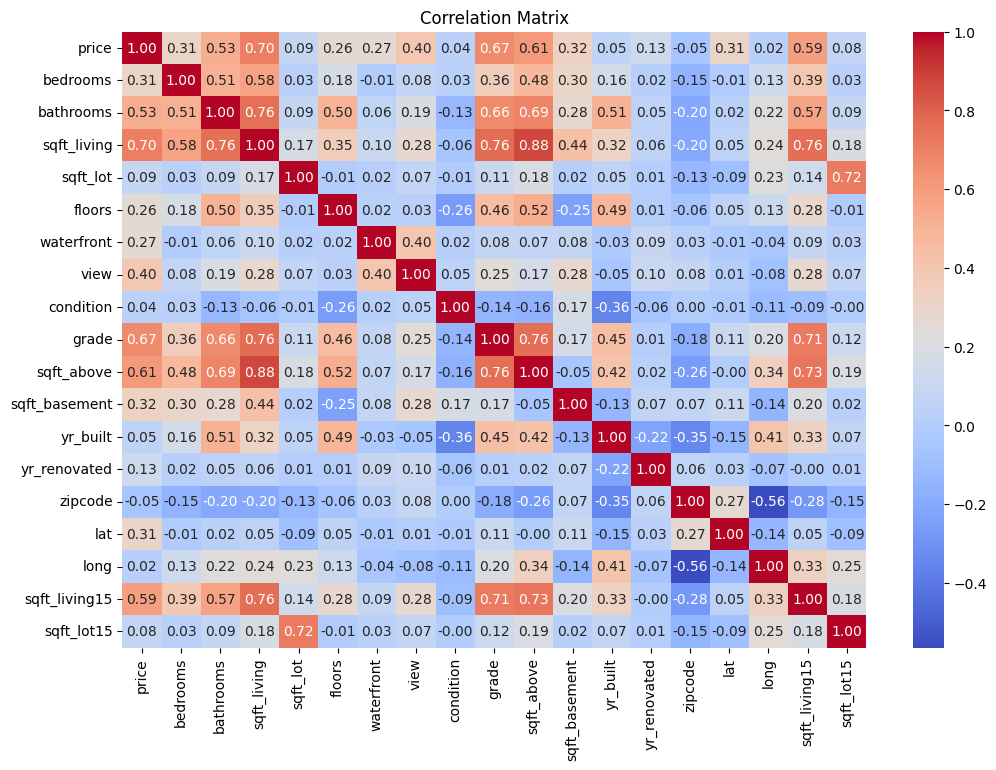

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

In [13]:
df.drop(['sqft_above','sqft_basement'],axis=1,inplace=True)
# drop because they are highly correlated with sqft_living 

In [14]:
df.drop(['sqft_living15','sqft_lot15'],axis=1,inplace=True)
# drop because they are highly correlated with sqft_living and sqft_lot 

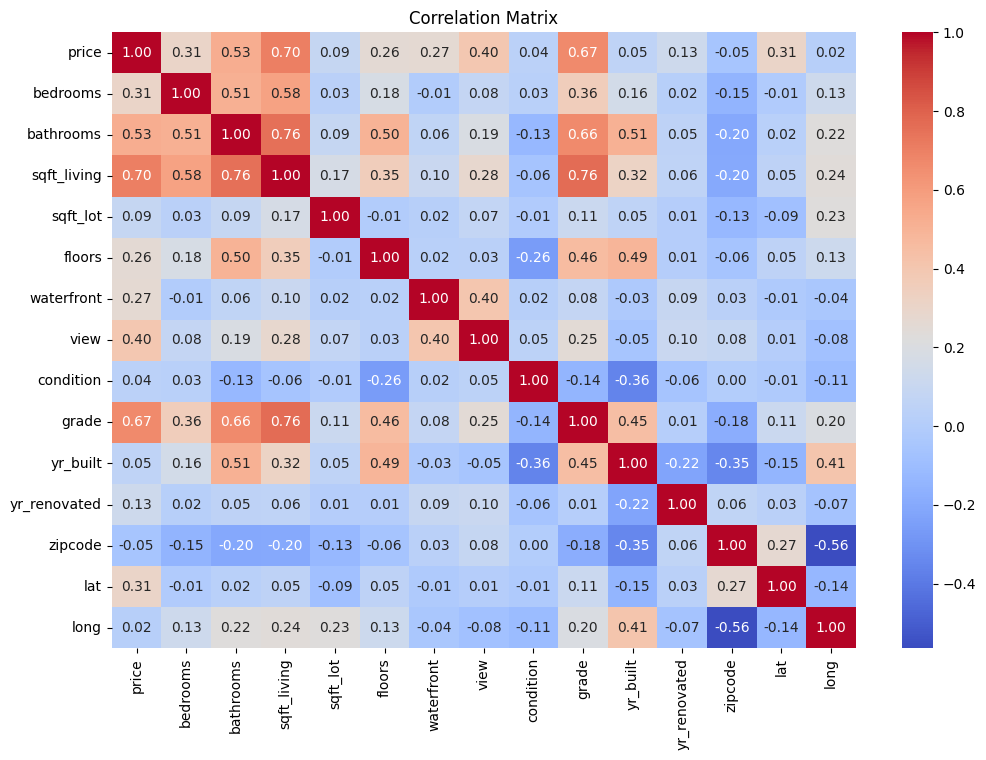

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

In [16]:
df['date'] = pd.to_datetime(df['date'])

df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month

df.drop('date', axis=1, inplace=True)

In [17]:
df = pd.get_dummies(df, columns=['zipcode'], drop_first=True)

In [18]:
X = df.drop('price', axis=1)
Y = df['price']

In [19]:
means = X.mean(numeric_only=True)   # mean of each numeric feature
stds = X.std(numeric_only=True)     # standard deviation of each numeric feature

# (X_norm = (X - means) / stds)
X = (X - means) / stds


In [20]:
print(X.shape[0])
print(Y.shape[0])

21613
21613


In [21]:
# First split: 70% train, 30% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=42
)

In [22]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

In [23]:
print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])   
print("Test set size:", X_test.shape[0])

Training set size: 15129
Validation set size: 3242
Test set size: 3242


In [24]:
# Convert Pandas DataFrame to lists and add bias term
def dataframe_to_list_with_bias(X_df):
    X_list = X_df.values.tolist()
    # add bias (intercept) as first column
    return [[1] + row for row in X_list]

X_train_list = dataframe_to_list_with_bias(X_train)
X_val_list   = dataframe_to_list_with_bias(X_val)
X_test_list  = dataframe_to_list_with_bias(X_test)

y_train_list = y_train.tolist()
y_val_list   = y_val.tolist()
y_test_list  = y_test.tolist()

In [67]:
# Evaluation metrics for regression
def mse(y_true, y_pred):
    n = len(y_true)
    total_error = 0.0
    for i in range(n):
        total_error += (y_true[i] - y_pred[i])**2
    mse_value = total_error / n
    return mse_value

In [70]:
def gradient_descent(X, y, lr=0.001, epochs=100):
    n_samples = len(y)
    n_features = len(X[0])
    w = [0.0] * n_features  # initialize weights (including bias)
    mse_history = []        # to track MSE at each epoch

    for epoch in range(epochs):
        # Predict
        y_pred = []
        for row in X:
            pred = 0.0
            for i in range(n_features):
                pred += w[i] * row[i]
            y_pred.append(pred)

        # Compute gradients
        gradients = []
        for j in range(n_features):
            grad_j = 0.0
            for i in range(n_samples):
                grad_j += (y_pred[i] - y[i]) * X[i][j]
            grad_j = (2 / n_samples) * grad_j
            gradients.append(grad_j)

        # Update weights
        for j in range(n_features):
            w[j] -= lr * gradients[j]

        # Store MSE for this epoch
        current_mse = mse(y, y_pred)
        mse_history.append(current_mse)

        # Optional: print every 10 epochs
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR={lr}: MSE={current_mse:.2f}")

    return w, mse_history

In [71]:
weights,_ = gradient_descent(X_train_list, y_train_list, lr=0.001, epochs=100)

Epoch 0, LR=0.001: MSE=419702865749.11
Epoch 10, LR=0.001: MSE=398125152171.90
Epoch 20, LR=0.001: MSE=378195501826.19
Epoch 30, LR=0.001: MSE=359740800271.17
Epoch 40, LR=0.001: MSE=342609890501.99
Epoch 50, LR=0.001: MSE=326670543337.71
Epoch 60, LR=0.001: MSE=311806860951.60
Epoch 70, LR=0.001: MSE=297917050612.22
Epoch 80, LR=0.001: MSE=284911514920.67
Epoch 90, LR=0.001: MSE=272711212691.27


In [72]:
learning_rates = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]
epochs = 100

mse_histories = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")
    w, mse_history = gradient_descent(X_train_list, y_train_list, lr=lr, epochs=epochs)
    mse_histories[lr] = mse_history


Training with learning rate = 1e-05
Epoch 0, LR=1e-05: MSE=419702865749.11
Epoch 10, LR=1e-05: MSE=419478756708.63
Epoch 20, LR=1e-05: MSE=419254830832.52
Epoch 30, LR=1e-05: MSE=419031087911.07
Epoch 40, LR=1e-05: MSE=418807527734.89
Epoch 50, LR=1e-05: MSE=418584150094.85
Epoch 60, LR=1e-05: MSE=418360954782.14
Epoch 70, LR=1e-05: MSE=418137941588.21
Epoch 80, LR=1e-05: MSE=417915110304.82
Epoch 90, LR=1e-05: MSE=417692460724.01

Training with learning rate = 0.0001
Epoch 0, LR=0.0001: MSE=419702865749.11
Epoch 10, LR=0.0001: MSE=417469584594.24
Epoch 20, LR=0.0001: MSE=415254441694.26
Epoch 30, LR=0.0001: MSE=413057231035.69
Epoch 40, LR=0.0001: MSE=410877749430.36
Epoch 50, LR=0.0001: MSE=408715796473.47
Epoch 60, LR=0.0001: MSE=406571174502.24
Epoch 70, LR=0.0001: MSE=404443688555.21
Epoch 80, LR=0.0001: MSE=402333146332.17
Epoch 90, LR=0.0001: MSE=400239358154.66

Training with learning rate = 0.001
Epoch 0, LR=0.001: MSE=419702865749.11
Epoch 10, LR=0.001: MSE=398125152171.90
E

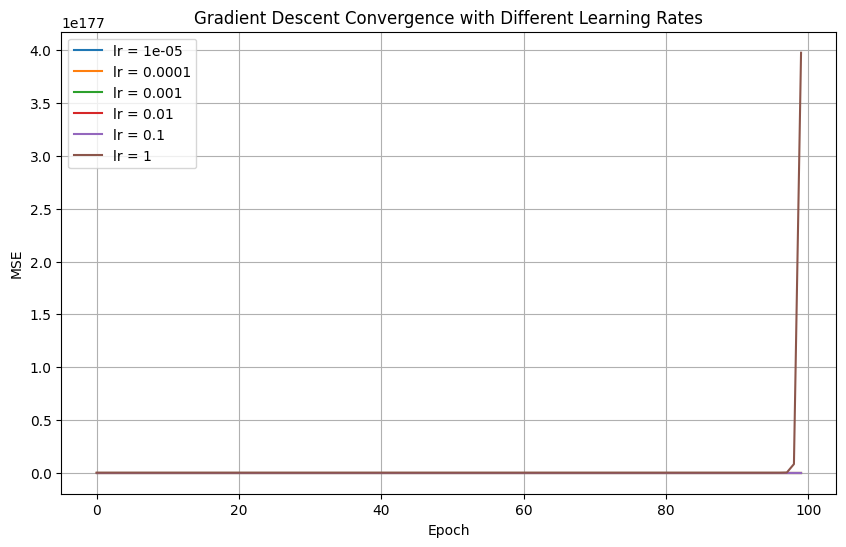

In [73]:
plt.figure(figsize=(10,6))

for lr, history in mse_histories.items():
    plt.plot(range(epochs), history, label=f"lr = {lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Gradient Descent Convergence with Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

Best Learning Rate: 0.1
Final MSE: 25605810399.98187


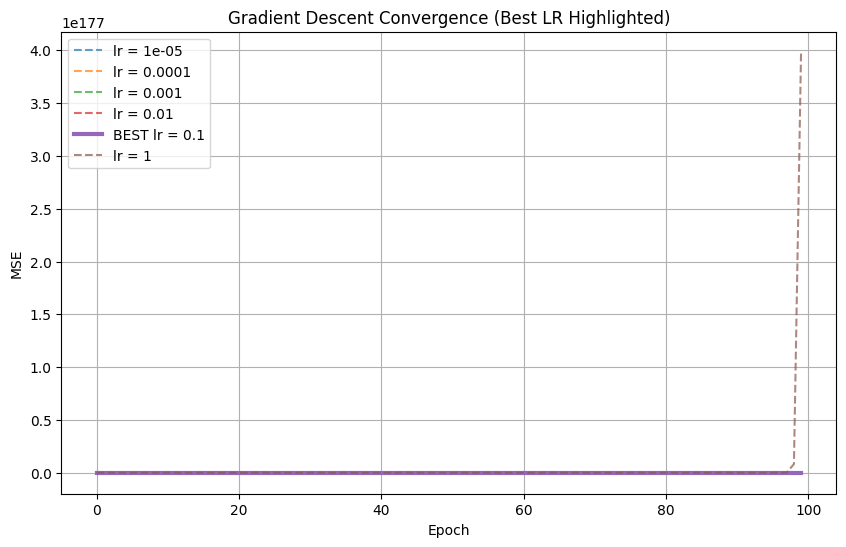

In [ ]:
best_lr = None
best_final_mse = float("inf")

for lr, history in mse_histories.items():
    final_mse = history[-1]
    if final_mse < best_final_mse:
        best_final_mse = final_mse
        best_lr = lr

print("Best Learning Rate:", best_lr)
print("Final MSE:", best_final_mse)

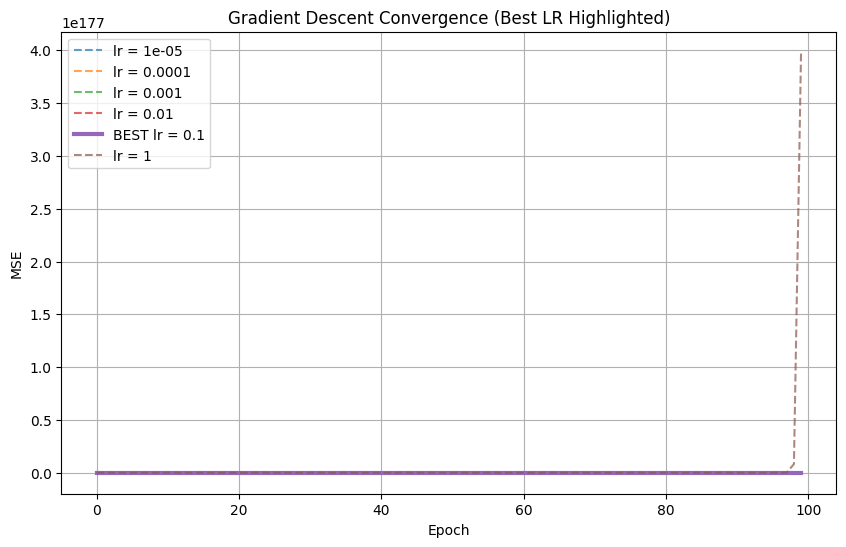

In [75]:
plt.figure(figsize=(10, 6))

for lr, history in mse_histories.items():
    if lr == best_lr:
        plt.plot(range(len(history)), history, linewidth=3, label=f"BEST lr = {lr}")
    else:
        plt.plot(range(len(history)), history, linestyle='--', alpha=0.7, label=f"lr = {lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Gradient Descent Convergence (Best LR Highlighted)")
plt.legend()
plt.grid(True)
plt.show()

In [78]:
def gradient_descent_with_regularization(X, y, lr=0.001, epochs=100, lambda_reg=0.0):
    n_samples = len(y)
    n_features = len(X[0])
    w = [0.0] * n_features  # initialize weights (including bias)
    mse_history_reg = []        # to track MSE at each epoch

    for epoch in range(epochs):
        # Predict
        y_pred = []
        for row in X:
            pred = 0.0
            for i in range(n_features):
                pred += w[i] * row[i]
            y_pred.append(pred)

        # Compute gradients
        gradients = []
        for j in range(n_features):
            grad_j = 0.0
            for i in range(n_samples):
                grad_j += (y_pred[i] - y[i]) * X[i][j]
            grad_j = (2 / n_samples) * grad_j
            if j != 0: # to avoid regularizing the bias term
                grad_j += 2 * lambda_reg * w[j]
            gradients.append(grad_j)

        # Update weights
        for j in range(n_features):
            w[j] -= lr * gradients[j]

        # Store MSE for this epoch
        current_mse = mse(y, y_pred)
        mse_history_reg.append(current_mse)

        # Optional: print every 10 epochs
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR={lr}, Lambda={lambda_reg}: MSE={current_mse:.2f}")

    return w, mse_history_reg

In [83]:
lambdas = [0.01, 0.1,0, 1, 10]
lambda_histories = {}

for lam in lambdas:
    w, history = gradient_descent_with_regularization(
        X_train_list,
        y_train_list,
        lr=best_lr,
        epochs=epochs,
        lambda_reg=lam
    )
    
    lambda_histories[lam] = history   

Epoch 0, LR=0.1, Lambda=0.01: MSE=419702865749.11
Epoch 10, LR=0.1, Lambda=0.01: MSE=30649003074.52
Epoch 20, LR=0.1, Lambda=0.01: MSE=26235894161.41
Epoch 30, LR=0.1, Lambda=0.01: MSE=25915263765.79
Epoch 40, LR=0.1, Lambda=0.01: MSE=25792664848.41
Epoch 50, LR=0.1, Lambda=0.01: MSE=25727209820.49
Epoch 60, LR=0.1, Lambda=0.01: MSE=25688003865.04
Epoch 70, LR=0.1, Lambda=0.01: MSE=25662898693.56
Epoch 80, LR=0.1, Lambda=0.01: MSE=25646039402.57
Epoch 90, LR=0.1, Lambda=0.01: MSE=25634270047.70
Epoch 0, LR=0.1, Lambda=0.1: MSE=419702865749.11
Epoch 10, LR=0.1, Lambda=0.1: MSE=31163658502.32
Epoch 20, LR=0.1, Lambda=0.1: MSE=26741172782.21
Epoch 30, LR=0.1, Lambda=0.1: MSE=26438659087.05
Epoch 40, LR=0.1, Lambda=0.1: MSE=26334212719.11
Epoch 50, LR=0.1, Lambda=0.1: MSE=26283830498.39
Epoch 60, LR=0.1, Lambda=0.1: MSE=26256680370.19
Epoch 70, LR=0.1, Lambda=0.1: MSE=26241059855.01
Epoch 80, LR=0.1, Lambda=0.1: MSE=26231666174.22
Epoch 90, LR=0.1, Lambda=0.1: MSE=26225837221.70
Epoch 0, L

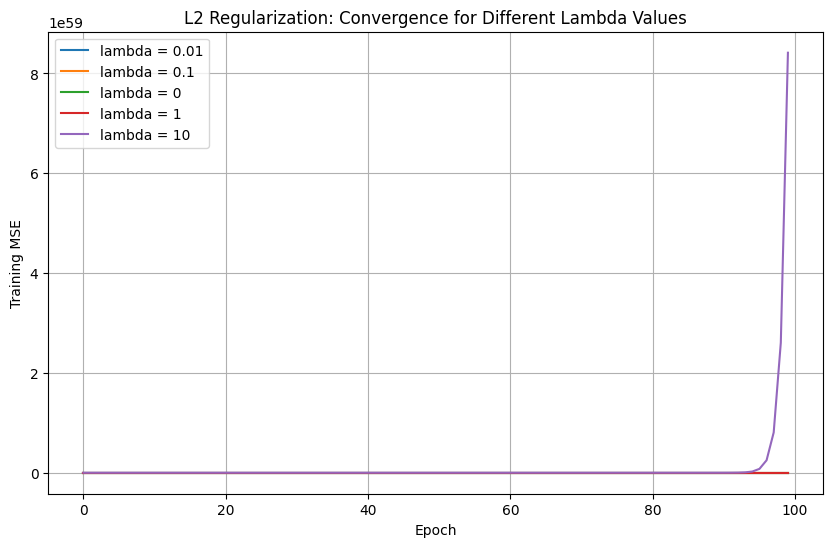

In [84]:
plt.figure(figsize=(10,6))

for lam, history in lambda_histories.items():
    plt.plot(range(len(history)), history, label=f"lambda = {lam}")

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("L2 Regularization: Convergence for Different Lambda Values")
plt.legend()
plt.grid(True)
plt.show()

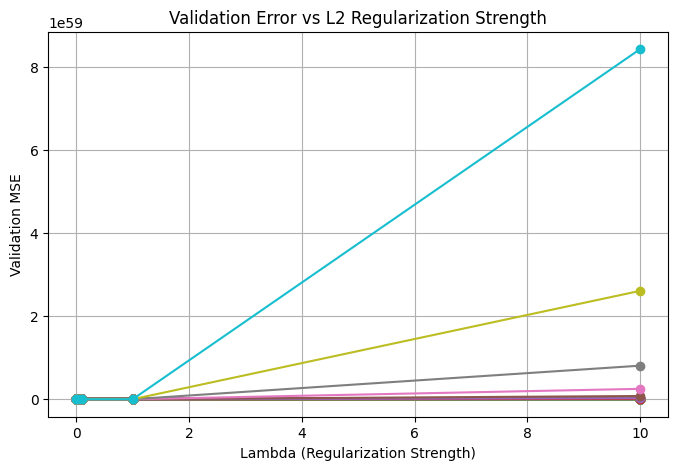

In [85]:
plt.figure(figsize=(8,5))

lams = list(lambda_histories.keys())
vals = list(lambda_histories.values())

plt.plot(lams, vals, marker='o')

plt.xlabel("Lambda (Regularization Strength)")
plt.ylabel("Validation MSE")
plt.title("Validation Error vs L2 Regularization Strength")
plt.grid(True)
plt.show()

In [87]:
best_lambda = min(lambda_histories, key=lambda_histories.get)

print("Best Lambda:", best_lambda)
print("Best Validation MSE:", lambda_histories[best_lambda][-1])

Best Lambda: 0
Best Validation MSE: 25605810399.98187


In [26]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
best_lambda = 0.1 

# --- Standard Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_train = lr_model.predict(X_train)
y_pred_val = lr_model.predict(X_val)
y_pred_test = lr_model.predict(X_test)

print("Linear Regression (scikit-learn)")
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Validation MSE:", mean_squared_error(y_val, y_pred_val))
print("Test MSE:", mean_squared_error(y_test, y_pred_test))

# --- Ridge Regression with Best Lambda ---
ridge_model = Ridge(alpha=best_lambda)
ridge_model.fit(X_train, y_train)
y_ridge_pred_train = ridge_model.predict(X_train)
y_ridge_pred_val = ridge_model.predict(X_val)
y_ridge_pred_test = ridge_model.predict(X_test)

print("\nRidge Regression (scikit-learn, alpha={})".format(best_lambda))
print("Train MSE:", mean_squared_error(y_train, y_ridge_pred_train))
print("Validation MSE:", mean_squared_error(y_val, y_ridge_pred_val))
print("Test MSE:", mean_squared_error(y_test, y_ridge_pred_test))

Linear Regression (scikit-learn)
Train MSE: 25543185767.19969
Validation MSE: 27125936101.72224
Test MSE: 28996556425.850807

Ridge Regression (scikit-learn, alpha=0.1)
Train MSE: 25543186062.264194
Validation MSE: 27125831491.39767
Test MSE: 28996594882.269867
